In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize
from astroML import stats as astroMLstats

In [2]:
#numero di dati che voglio usare
N_draws = 1000
mu = 1
sigma = 0.02
sigma_vec = np.linspace(0.1, 1, 100)

#genero le chi
chi = uniform.rvs(loc = 0, scale =  1, size = N_draws)

#genero i dati della massa
M = norm.rvs(loc = mu , scale = sigma, size = N_draws)


calcolo la distribuzione della massa irriducibile

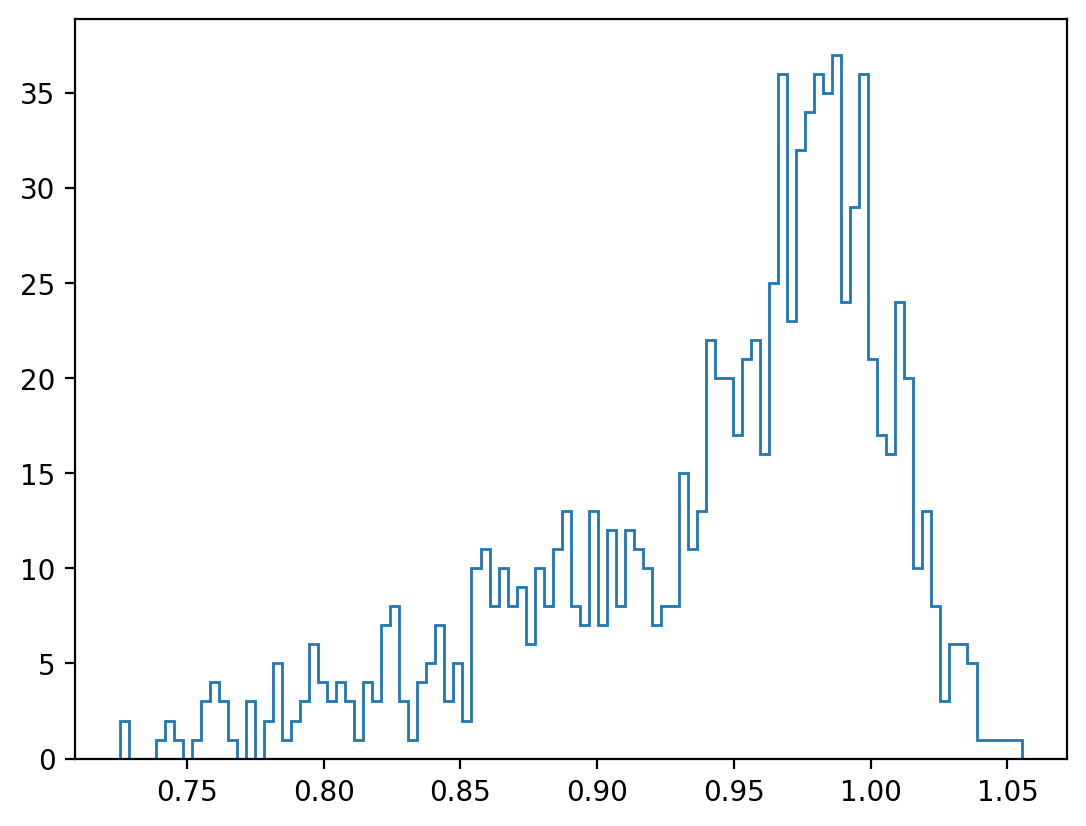

In [3]:
#calcolo la funzione f(chi)
f_chi = np.sqrt((1 + np.sqrt(1 - chi**2))/2)

#plotto la massa irriducibile
M_irr = f_chi * M

Plot = M_irr

plt.hist(M_irr, histtype='step', bins = 100)
plt.show()

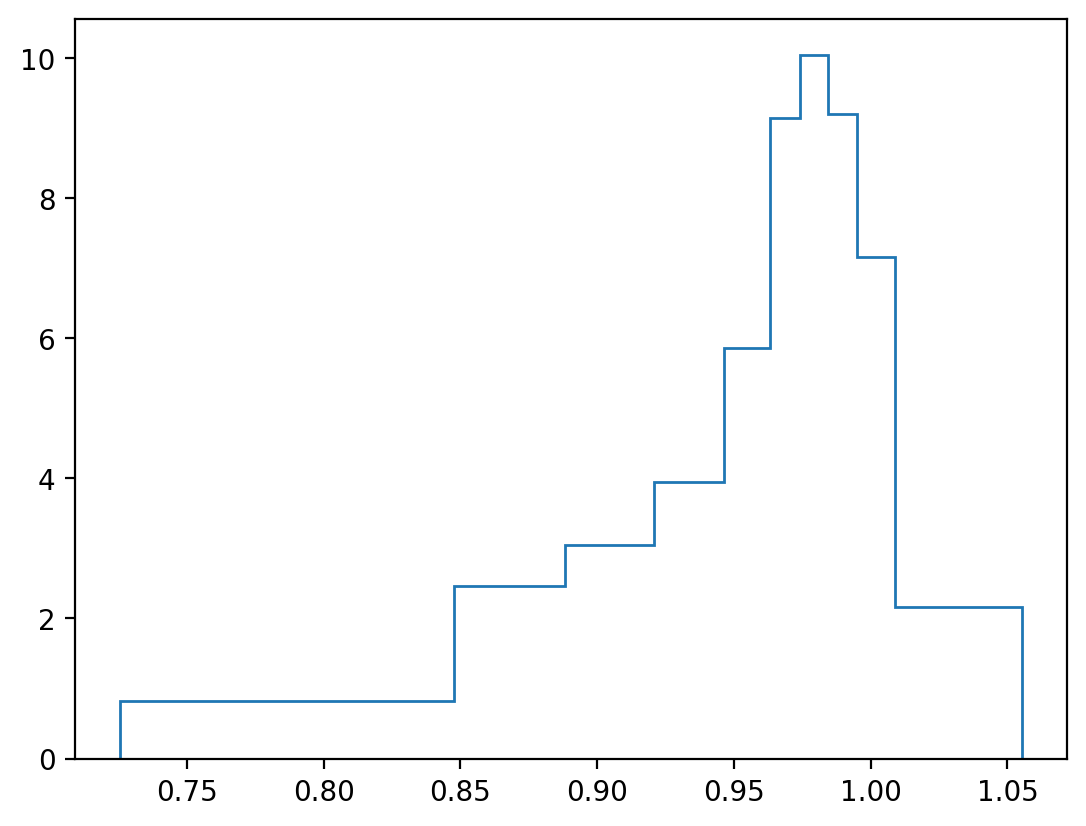

In [4]:
#create the histogram by sorting elements and filling bins with same number
B = 100

binsM = np.append(np.sort(M_irr)[::B], np.max(M_irr))
plt.hist(M_irr, histtype='step', bins = binsM, density = True)
plt.show()


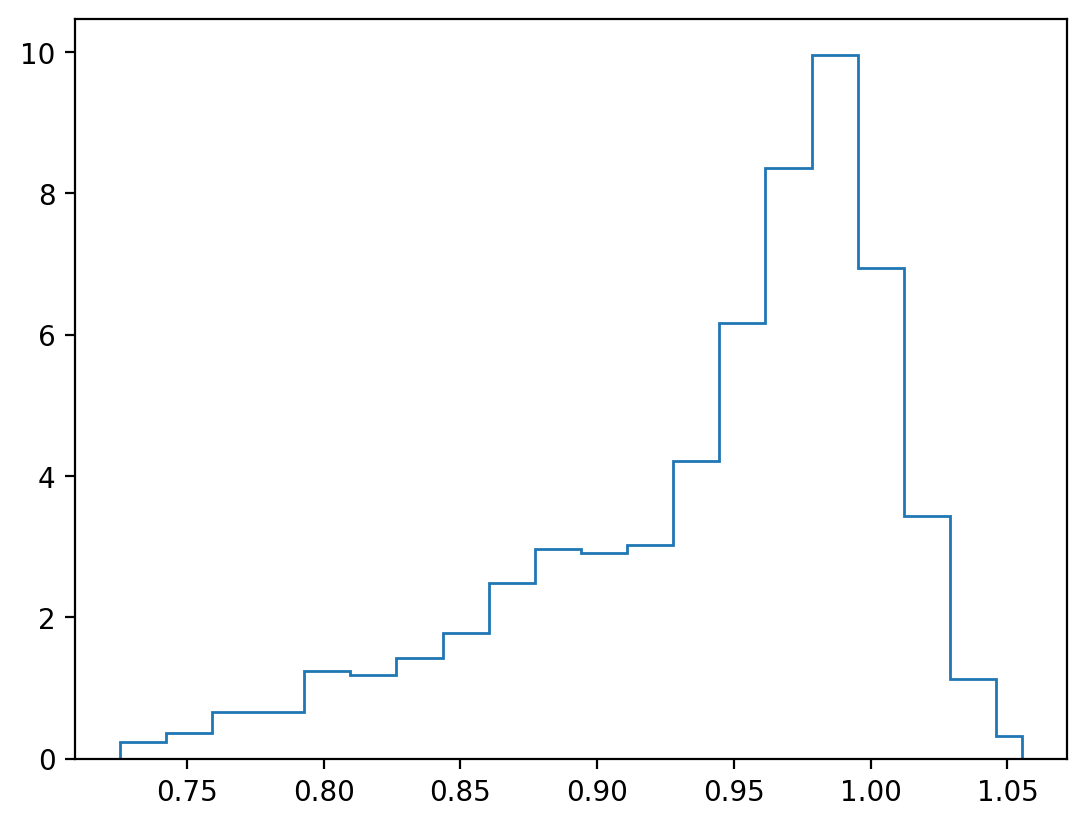

In [5]:
#histogramming using Freedman-Diaconis rule
from astroML import stats as astroMLstats

#calcolo sigma come se fosse gaussiana
sigmaG = astroMLstats.sigmaG(M_irr)

#calcolo dimensione Bins con regola Freedman-Diaconis
binsize = (2.7 * sigmaG)/(N_draws**(1/3)) 

#calcolo i singoli bin
binFreed = np.append(np.arange(start=np.min(M_irr), stop=np.max(M_irr), step=binsize), np.max(M_irr))
plt.hist(M_irr, bins=binFreed, density=True, histtype="step")
plt.show()

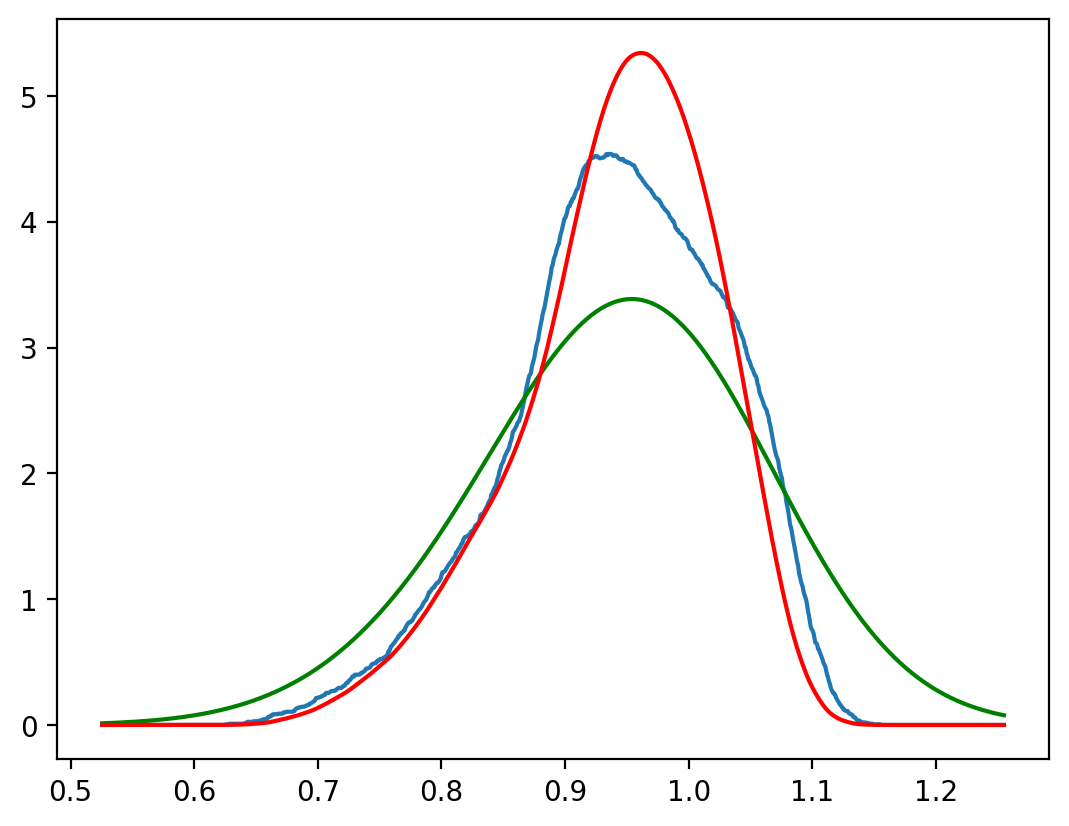

In [6]:
#plotting distribution using KDE (Kernel Density Estimation)
from sklearn.neighbors import KernelDensity

xgrid = np.linspace(np.min(M_irr) - 0.2 , np.max(M_irr) + 0.2, N_draws)

def kde_sklearn(data, bandwidth = 0.1, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:,np.newaxis]) # sklearn returns log(density)

    return np.exp(log_pdf)

plt.plot(xgrid, kde_sklearn(M_irr, bandwidth=0.1, kernel = "tophat"))
plt.plot(xgrid, kde_sklearn(M_irr, bandwidth=0.1, kernel = "gaussian"), color = 'g') 
plt.plot(xgrid, kde_sklearn(M_irr, bandwidth=0.1, kernel = "epanechnikov"),color = 'r')
plt.show()

Calcolo la KS in funzione della sigma 

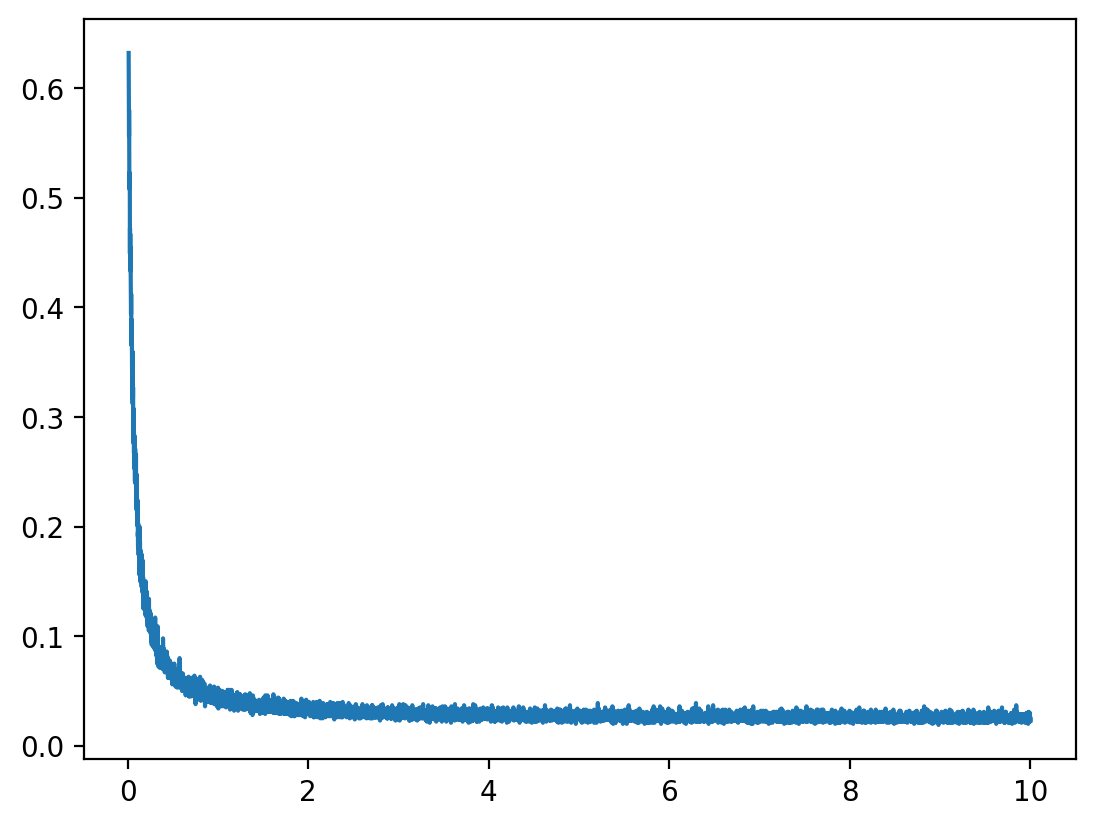

In [7]:
#calcolo KS test al variare della sigma
N_sigma = 10000
sigma_vec = np.linspace(0.01, 10, N_sigma)

#genero il vettore dei due ks test
ks_result1=np.zeros(N_sigma)
ks_result2=np.zeros(N_sigma)

#ciclo su tutte le sigma
for i in range (N_sigma):
    #genero le chi
    chi = uniform.rvs(loc = 0, scale =  1, size = N_draws)

    #genero i dati della massa
    M = norm.rvs(loc = mu , scale = sigma_vec[i], size = N_draws)

    #calcolo la funzione f(chi)
    f_chi = np.sqrt((1 + np.sqrt(1 - chi**2))/2)

    #plotto la massa irriducibile
    M_irr = f_chi * M
    
    f_chi_cdf = np.cumsum(f_chi)

    ks_result1[i] = stats.kstest(M_irr, M)[0]
    ks_result2[i] = stats.kstest(M_irr, f_chi)[0]

#plotto il ks test di M_irr in funzione di M
plt.plot(sigma_vec,ks_result1)
plt.show()

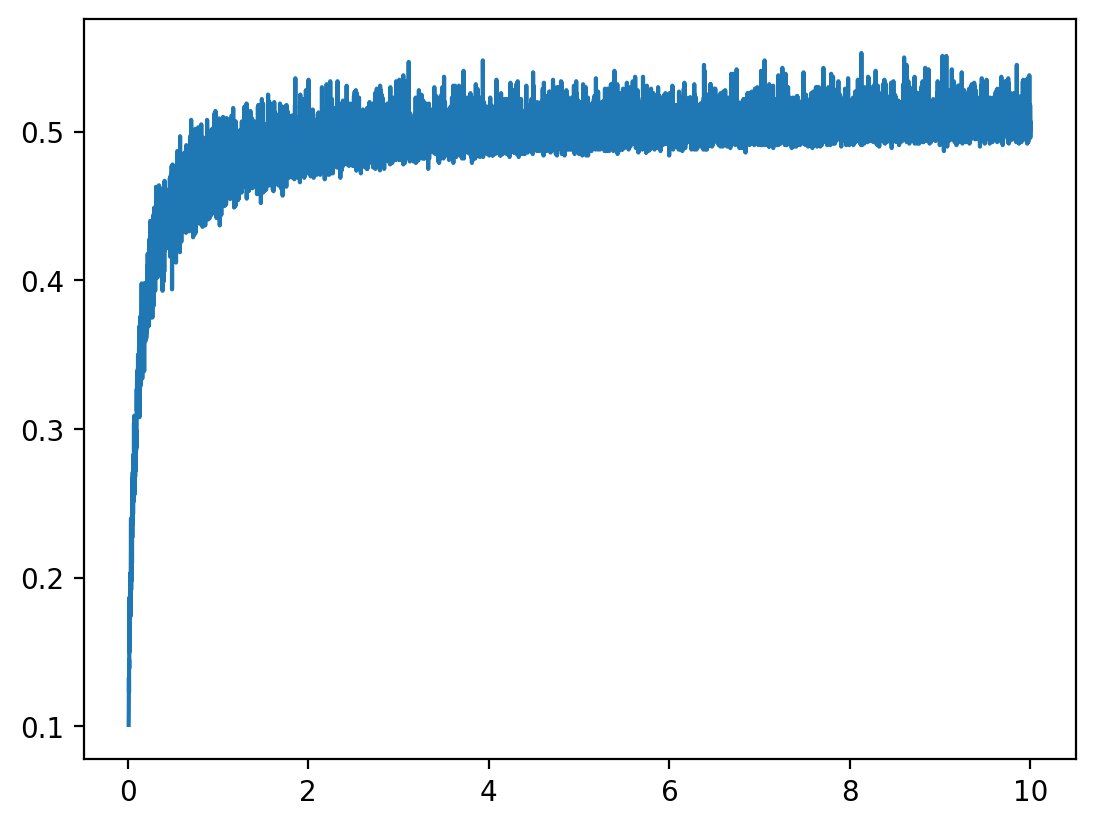

In [8]:
#plotto il ks test di M_irr in funzione di f_chi
plt.plot(sigma_vec,ks_result2)
plt.show()

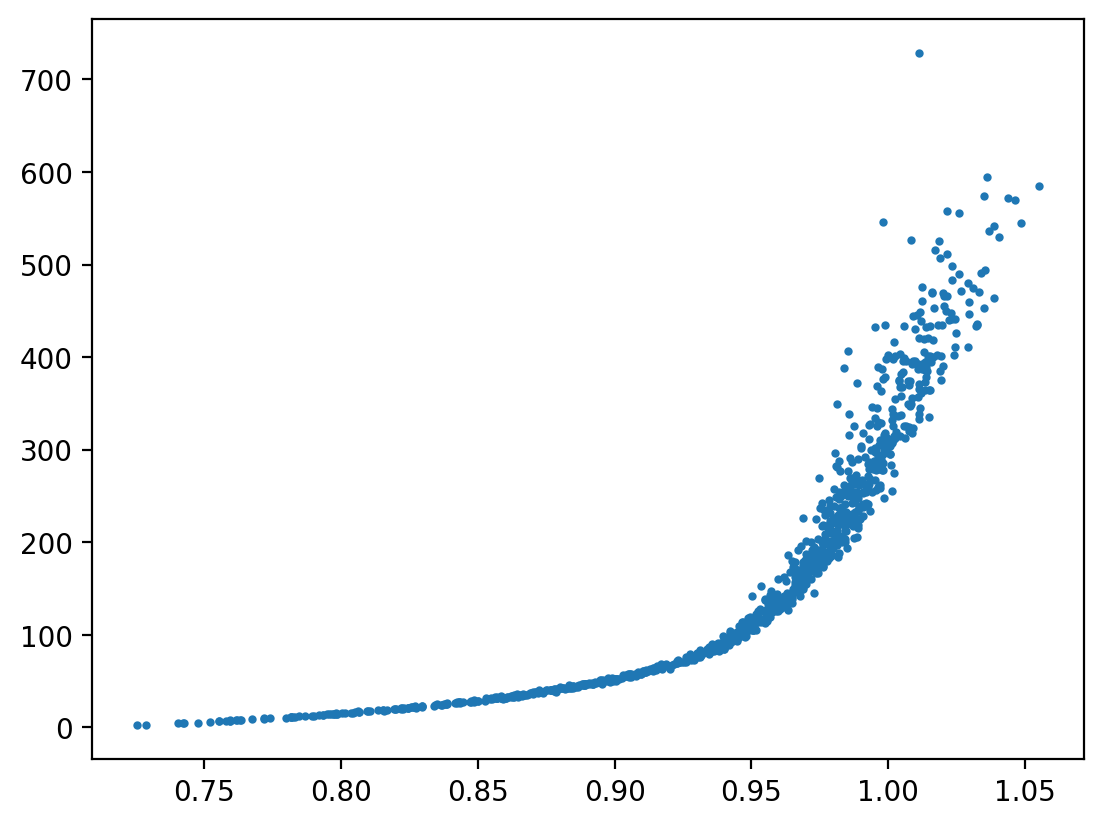

In [9]:
#Integro con monte carlo per ottenere la probabilità composta (M_irr):
from scipy.stats import truncnorm

#genero i dati con una prbabilià gaussiana
sigma = 0.02
N_montec = 100


integr = np.ones((N_draws, N_montec))

for j in range (N_draws):
    
    #definisco il nuovo centro e la nuova sigma della mia distribuzione
    locM = mu/Plot[j]
    sigmaM = np.sqrt((sigma/Plot[j])**2)
    
    #genero il limite superiore e il limite inferiore
    lower_bound = 1 # Limite inferiore
    upper_bound = np.sqrt(2) #limite superiore
    a, b = (lower_bound - (mu/Plot[j])) / (sigma/abs(Plot[j])), (upper_bound - (mu/Plot[j])) / (sigma/abs(Plot[j]))
    
    #genero la mia distribuzione 
    data = truncnorm.rvs(a ,b, loc = locM , scale = sigmaM, size = N_montec)
    
    for i in range (N_montec):
        integr[j][i] = (np.sqrt(2/3.14)/sigma)*((2/(data[i])**2) - 1) / (np.sqrt(data[i]**2 - 1))

P_M_irr = np.mean(integr , axis = 1)

plt.scatter(Plot,P_M_irr, s=4)

plt.show()


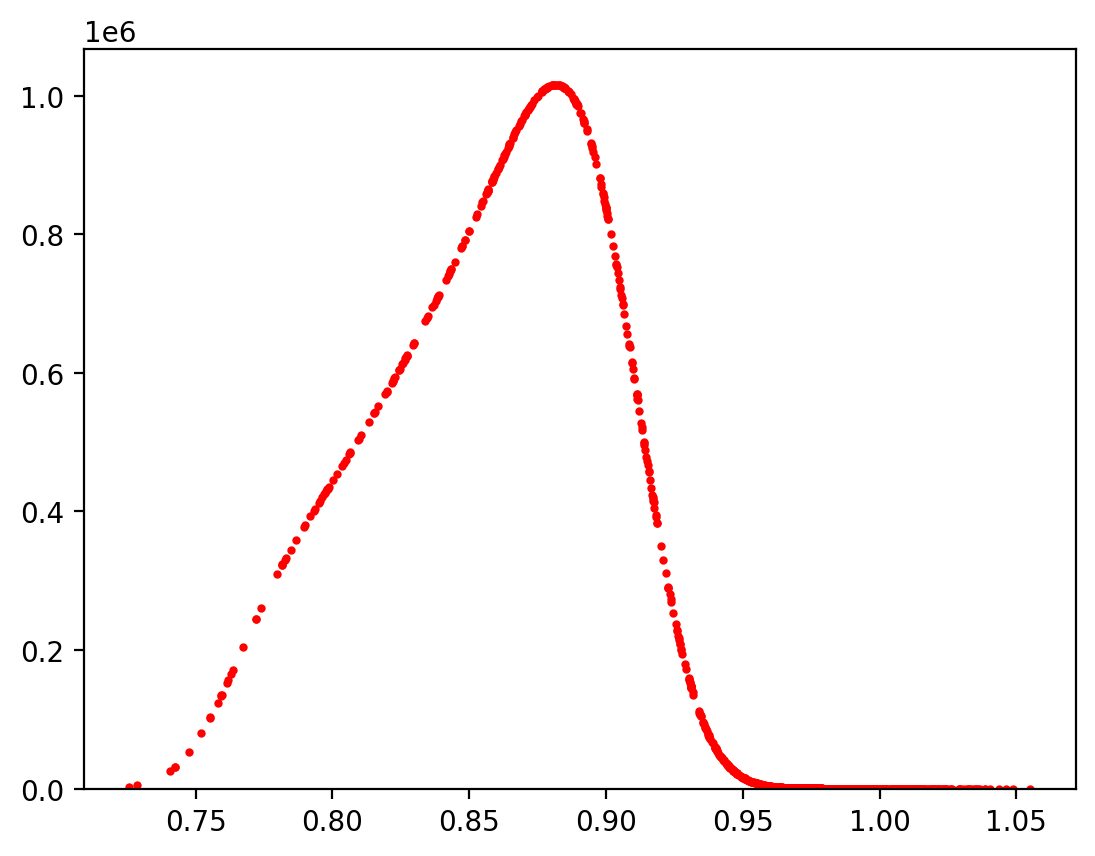

In [10]:
from scipy.integrate import trapezoid
precision = 100000
x = np.linspace (1.1 , np.sqrt(2) -0.1, precision)
f_x = np.ones((N_draws, precision))

for i in range(N_draws):
    f_x[i,:] = (np.sqrt(2/3.14)/sigma)*((2/(x)**2) - 1) / (np.sqrt(x**2 - 1)) * np.exp(-(Plot[i] * x - mu)**2/(2*sigma**2))

integral = scipy.integrate.trapezoid (f_x , axis = 1)
plt.scatter(Plot , integral , s = 4 , color = "red")
plt.hist(Plot)
plt.show()


CALCOLO VARIANZA DI MONTECARLO: